Initializing Bacco emulator...
Bacco power spectrum computed at 200 k-points
Setting up CCL cosmology...

GENERATING LSST SOURCE TOMOGRAPHIC BINS

Generating Y1 source bins...
Y1 bin centers:
  Bin 1: z = 0.114
  Bin 2: z = 0.226
  Bin 3: z = 0.355
  Bin 4: z = 0.536

Generating Y10 source bins...
Y10 bin centers:
  Bin 1: z = 0.130
  Bin 2: z = 0.268
  Bin 3: z = 0.426
  Bin 4: z = 0.640

Plotting LSST source bins...


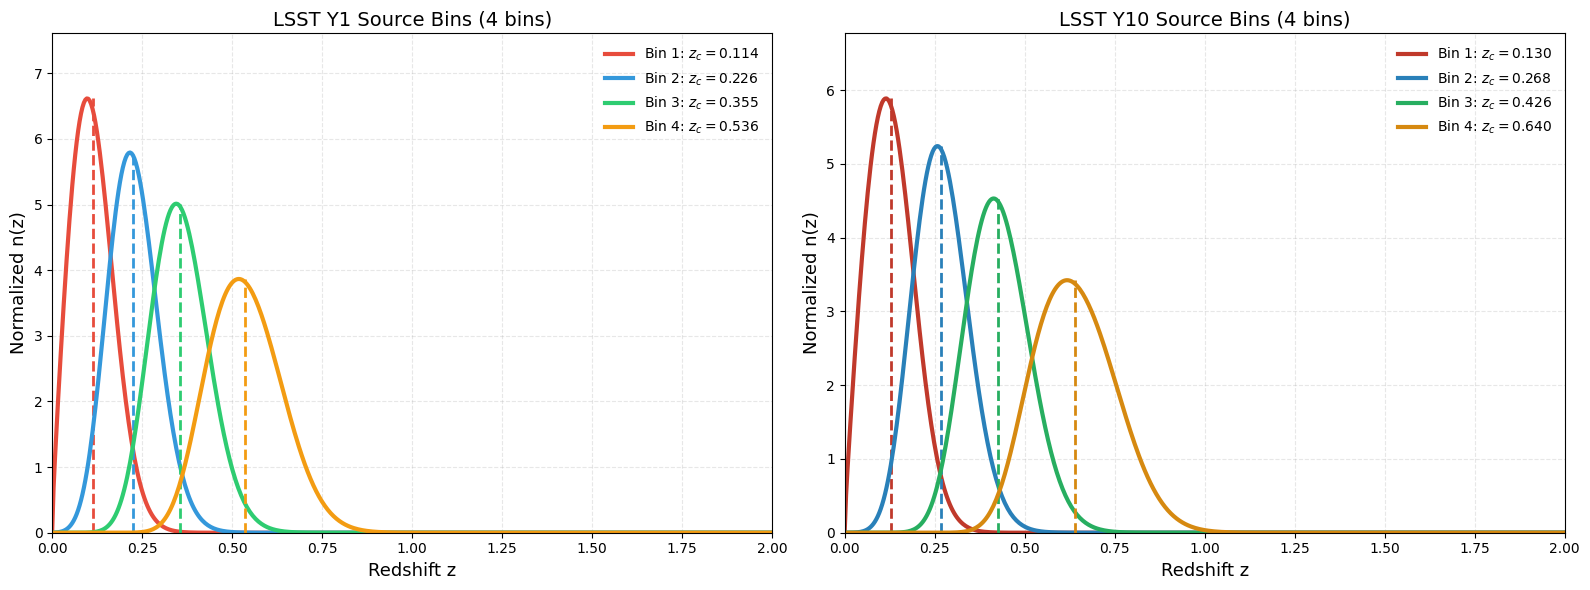


CREATING CCL TRACERS FOR TOMOGRAPHIC BINS

Creating Y1 tracers...
  Bin 1 tracer created
  Bin 2 tracer created
  Bin 3 tracer created
  Bin 4 tracer created

Creating Y10 tracers...
  Bin 1 tracer created
  Bin 2 tracer created
  Bin 3 tracer created
  Bin 4 tracer created

CMB lensing tracer created

INITIALIZING nDGP EMULATOR
Loading model and related data
All tests passed successfully.
nDGP emulator initialized successfully
nDGP emulator k range: [0.0157, 4.9947] h/Mpc
Bacco k range: [0.0100, 4.9032] h/Mpc
Using 185 k-points within nDGP range
Restricted k range: [0.0160, 4.9032] h/Mpc

COMPUTING ANGULAR POWER SPECTRA

Computing Y1 - GR...
  Bin 1: C_ell computed
  Bin 2: C_ell computed
  Bin 3: C_ell computed
  Bin 4: C_ell computed

Computing Y1 - nDGP_H0rc0.5...
  Bin 1: C_ell computed
  Bin 2: C_ell computed
  Bin 3: C_ell computed
  Bin 4: C_ell computed

Computing Y1 - nDGP_H0rc1.0...
  Bin 1: C_ell computed
  Bin 2: C_ell computed
  Bin 3: C_ell computed
  Bin 4: C_ell compu

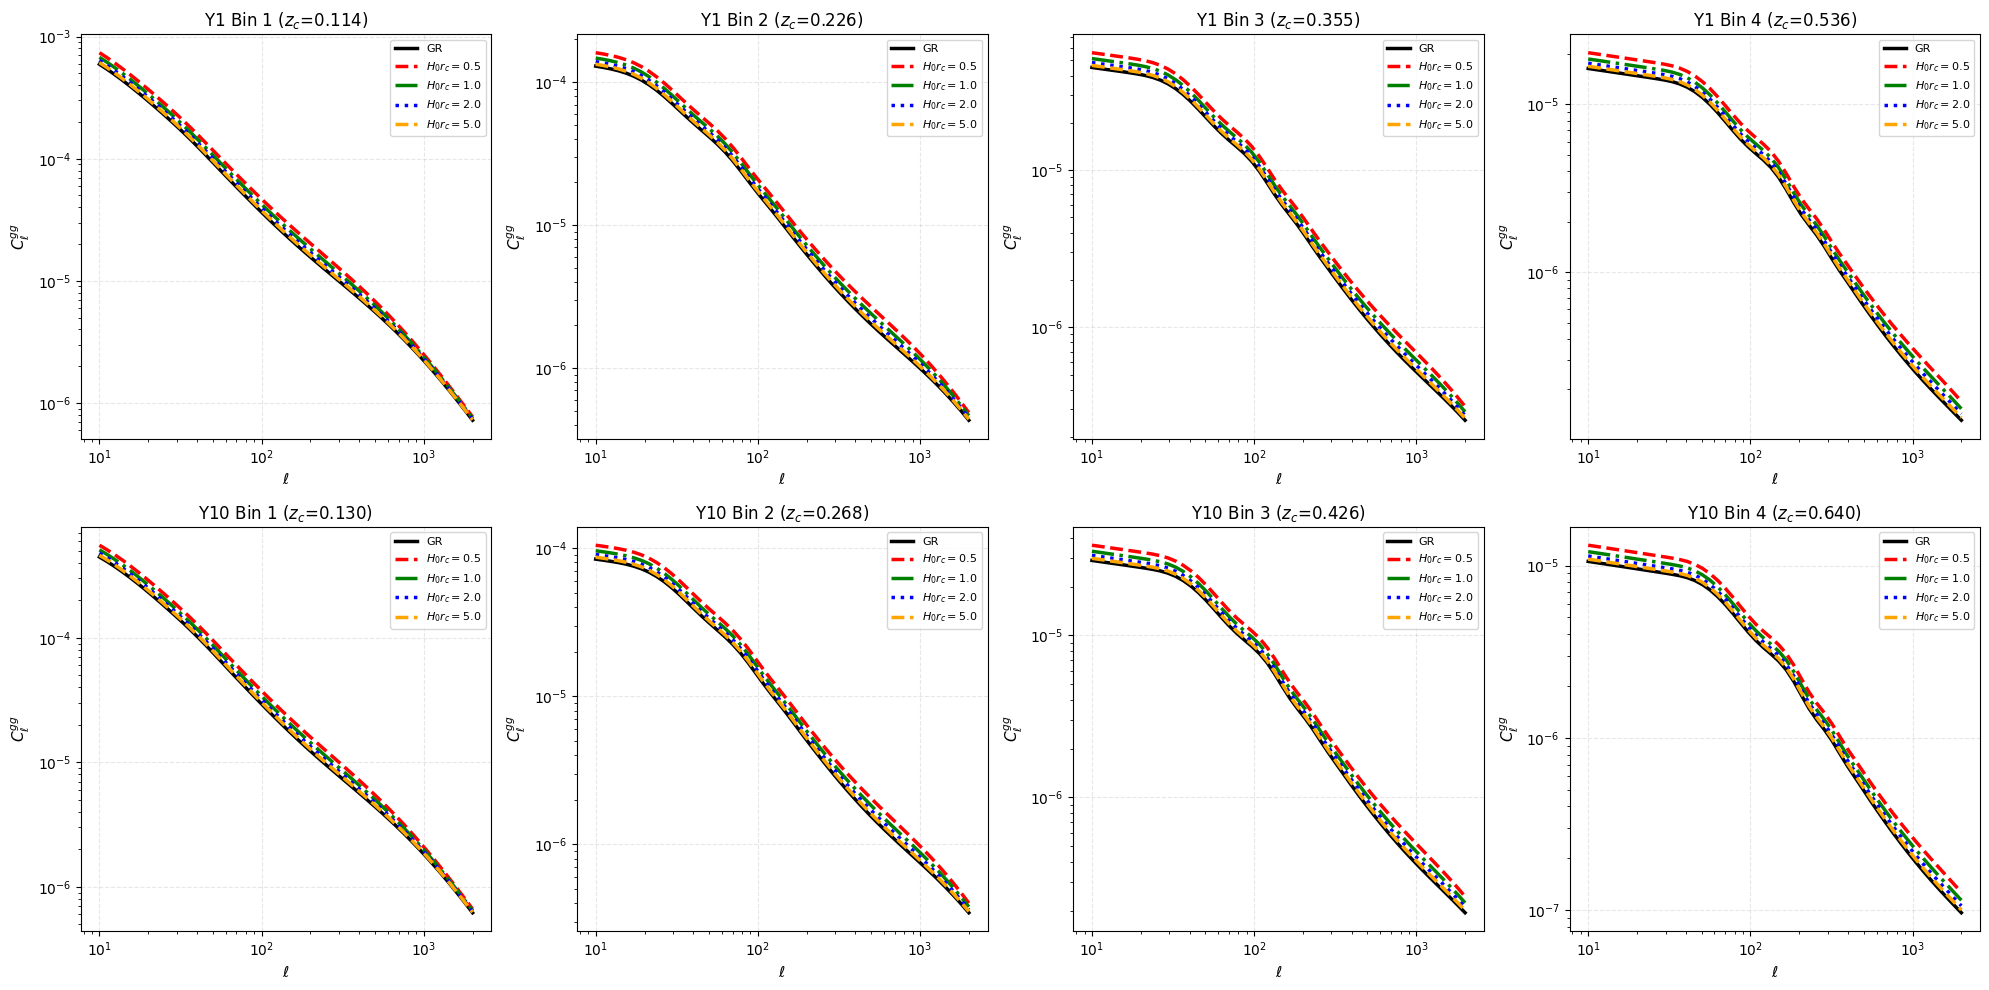

Generating cross-spectrum plots...


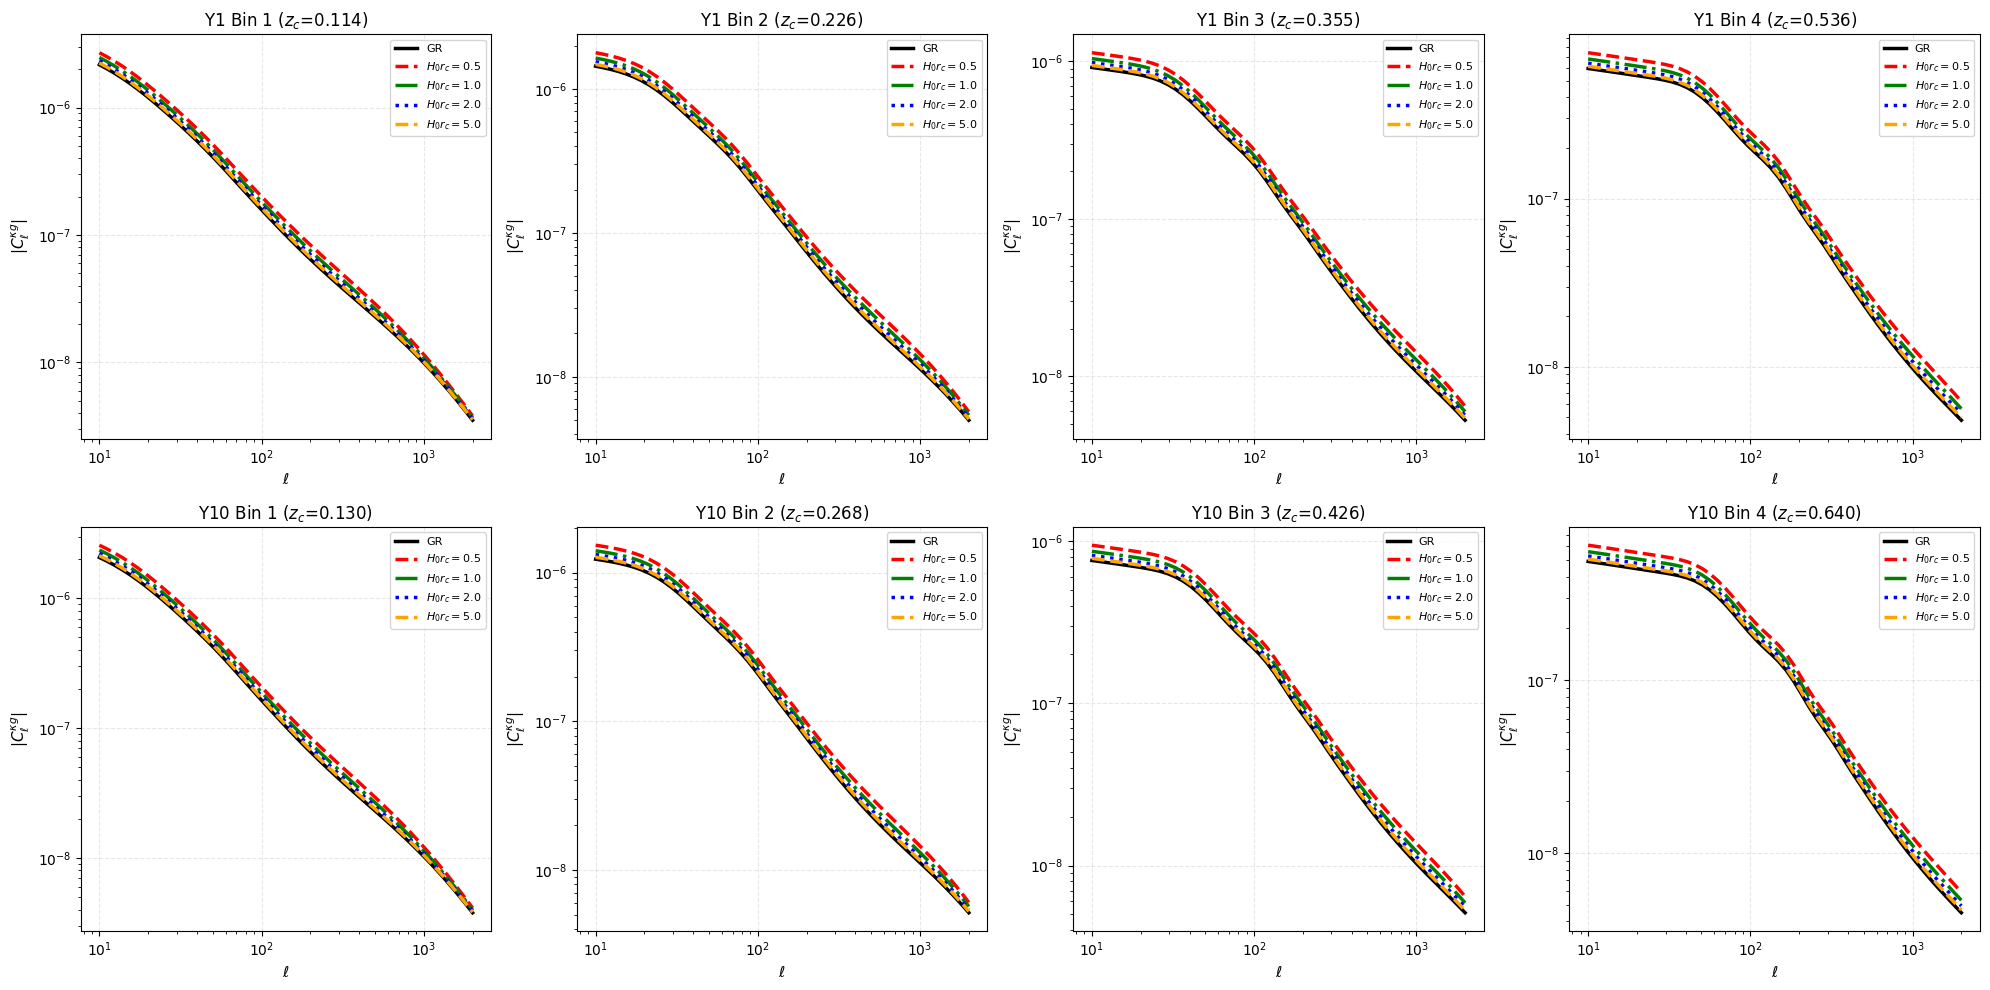

Generating gg ratio plots...


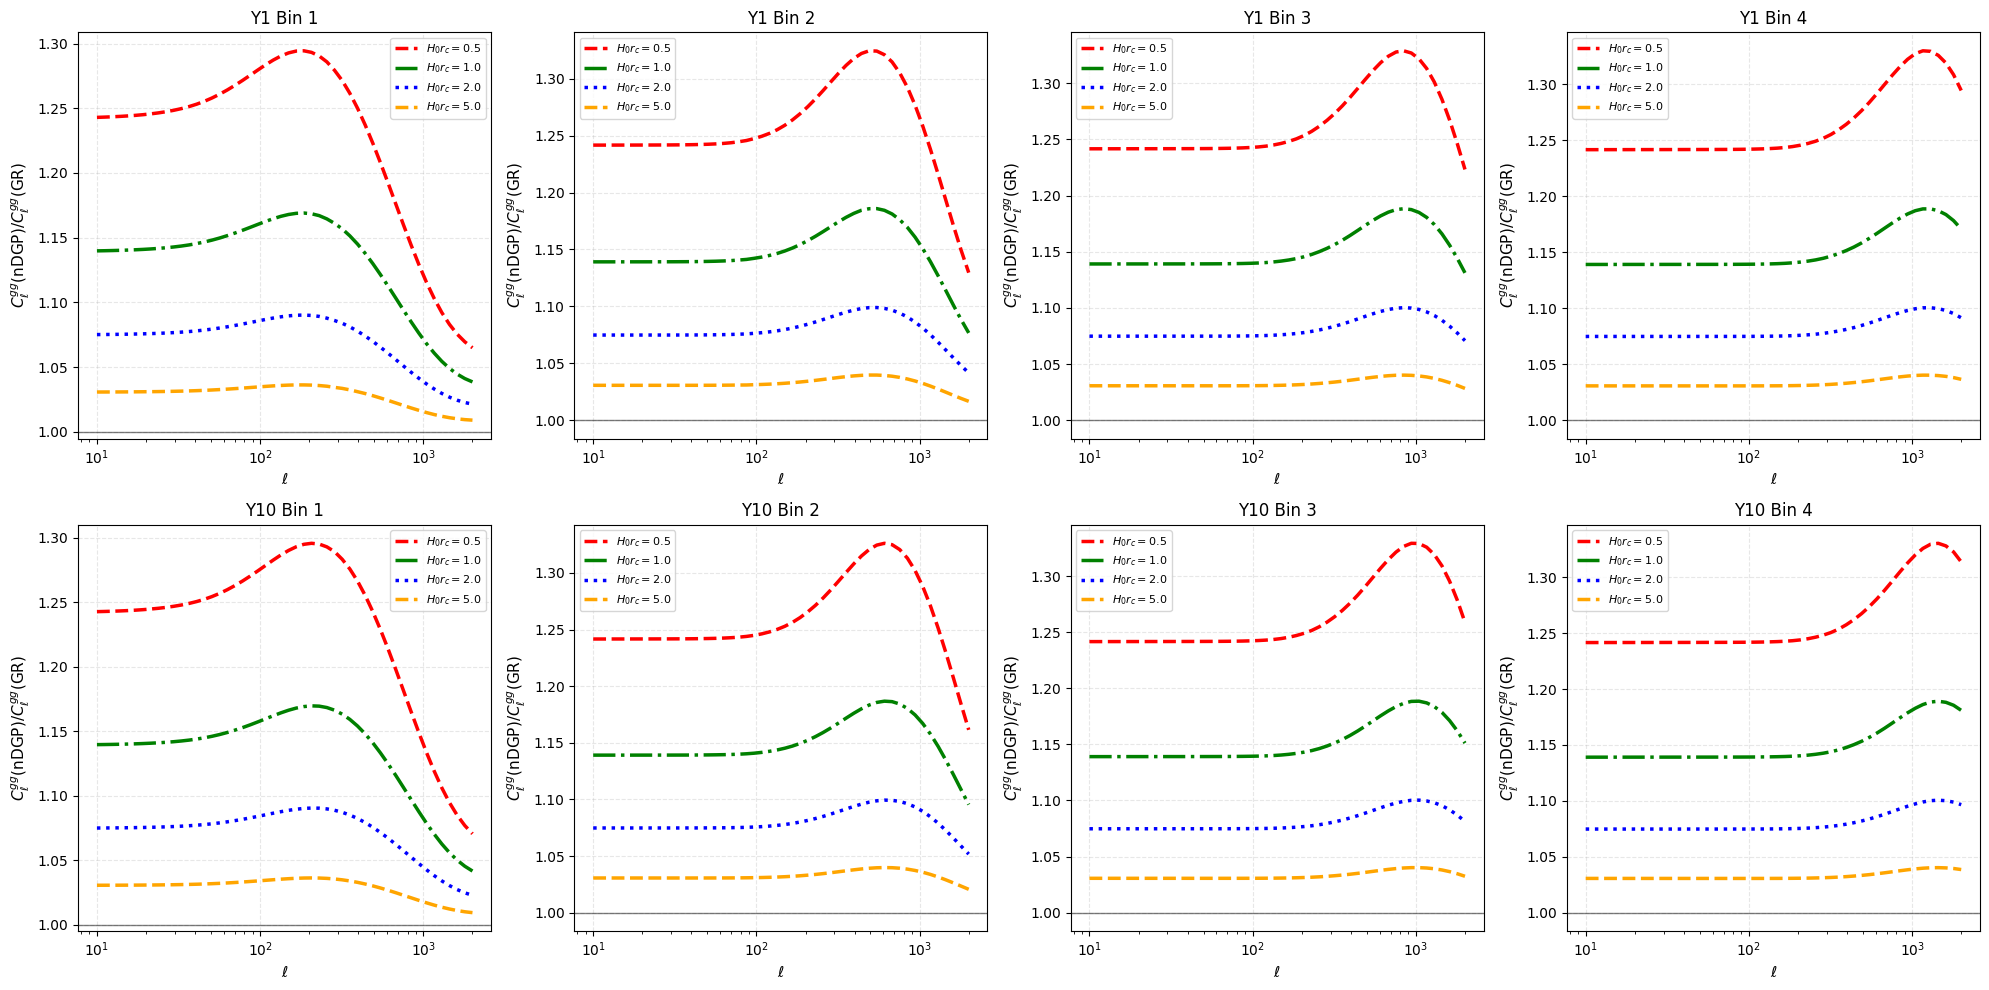

Generating kg ratio plots...


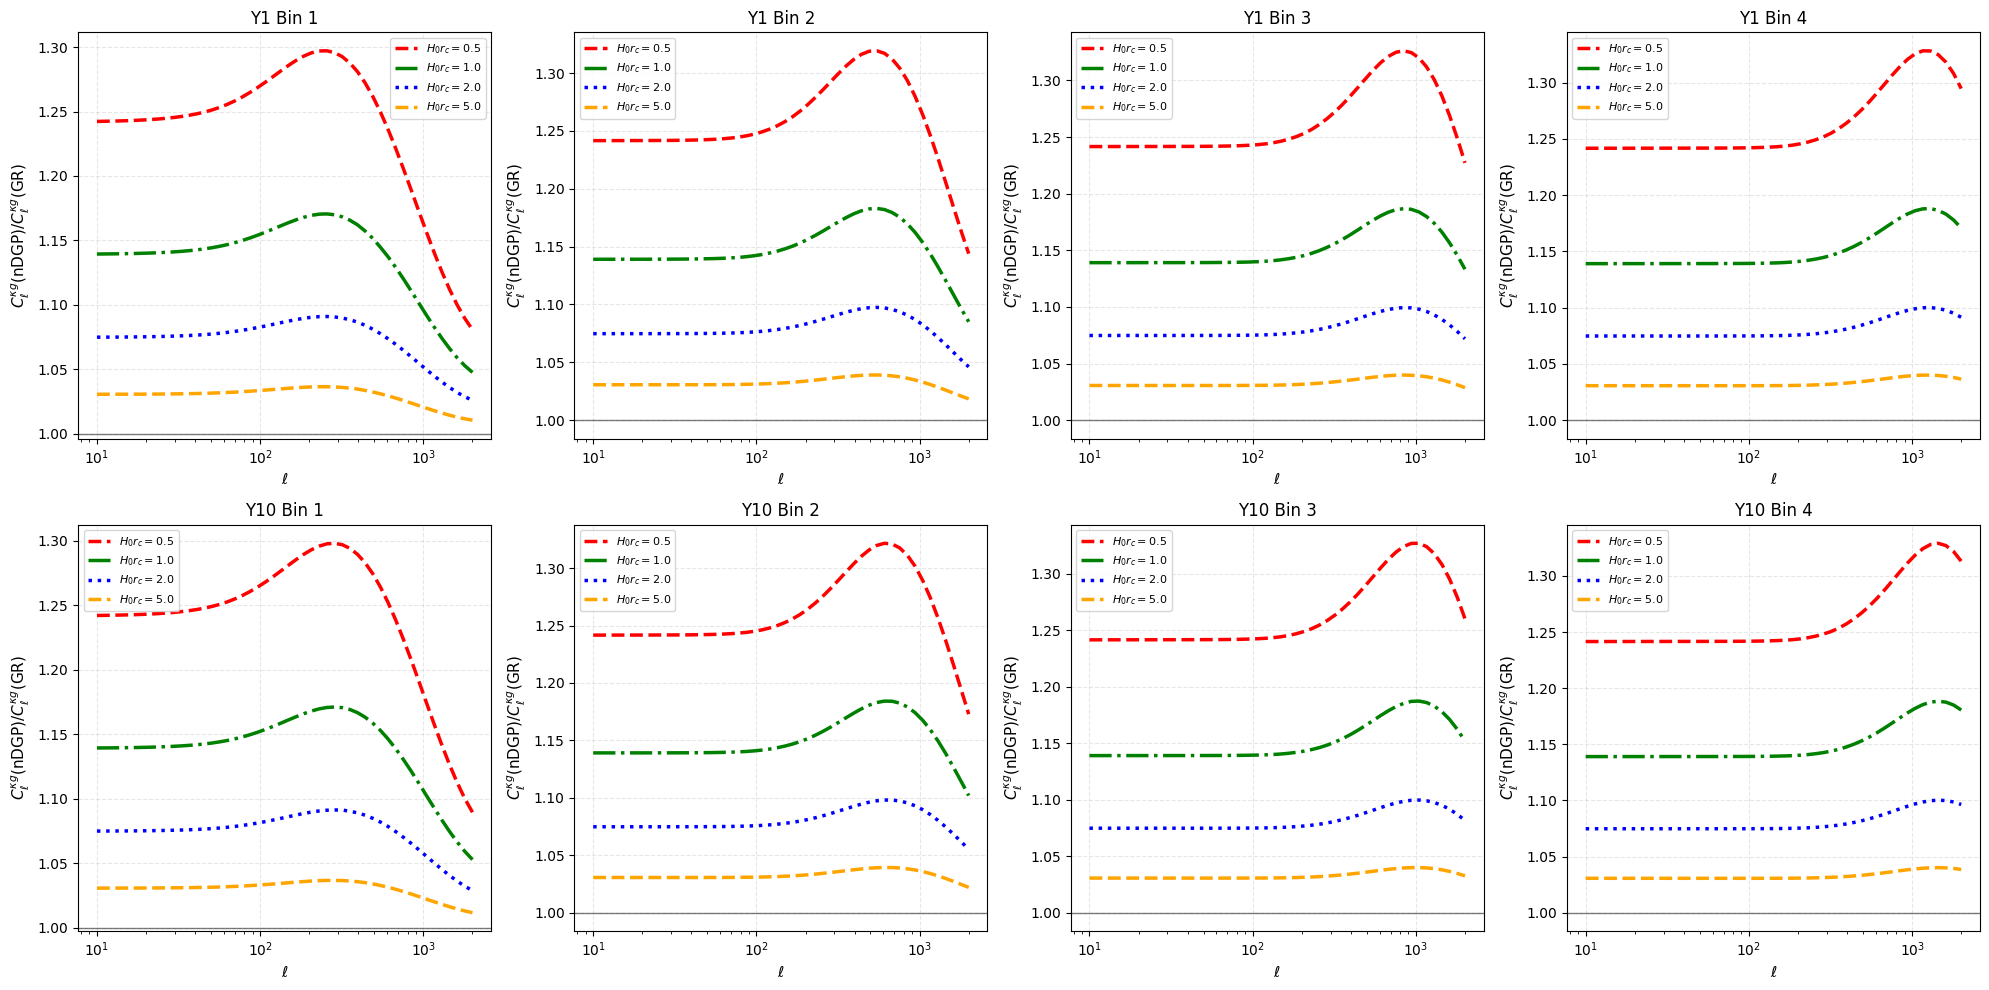


ALL COMPUTATIONS COMPLETE

Generated files:
  - lsst_source_bins.png
  - Cl_gg_tomographic_nDGP.png
  - Cl_kg_tomographic_nDGP.png
  - Cl_gg_ratio_tomographic_nDGP.png
  - Cl_kg_ratio_tomographic_nDGP.png


In [3]:
# -*- coding: utf-8 -*-
""" DGP Gravity Analysis with LSST Tomographic Binning

Complete pipeline for analyzing modified gravity (DGP model) using galaxy and CMB lensing data
with LSST Y1 and Y10 tomographic source bins.

Author: Adrita Khan
Date: 28 November, 2025
"""

# ========================================================
# Installation (run once)
# ========================================================
# pip install -q baccoemu scipy astropy pyccl
# pip install -q git+https://github.com/BartolomeoF/nDGPemu.git


# ========================================================
# Import Libraries with Suppression
# ========================================================
import os
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)
logging.getLogger("tensorflow").setLevel(logging.CRITICAL)

# Import without suppression to avoid file handle issues
import numpy as np
import matplotlib.pyplot as plt
import baccoemu
from nDGPemu import BoostPredictor, test_predict
import pyccl as ccl
from scipy.integrate import quad, simpson
from scipy.special import erf



# ========================================================
# LSST Redshift Distribution Functions
# ========================================================

def smail_distribution(z, z0, alpha, beta):
    """
    Smail-type redshift distribution: n(z) ∝ z^alpha * exp(-(z/z0)^beta)
    """
    return (z**alpha) * np.exp(-(z / z0)**beta)

def normalized_smail(z, z0, alpha, beta):
    """
    Normalized Smail distribution
    """
    dNdz_raw = smail_distribution(z, z0, alpha, beta)
    norm = np.trapz(dNdz_raw, z)
    return dNdz_raw / norm

def photo_z_kernel(z_true, z_photo, sigma_z, bias_z):
    """
    Photometric redshift error kernel (Gaussian)
    sigma_z: photometric scatter
    bias_z: photometric bias
    """
    z_mean = z_true + bias_z * (1 + z_true)
    sigma = sigma_z * (1 + z_true)
    return (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(
        -0.5 * ((z_photo - z_mean) / sigma)**2
    )

def tomographic_bin_phot(z_grid, dNdz_true, z_min, z_max, sigma_z, bias_z):
    """
    Compute tomographic bin with photometric uncertainties using convolution.
    
    n_i(z_true) = ∫ dz_photo n_true(z_true) P(z_photo|z_true) Θ(z_photo ∈ [z_min, z_max])
    
    Using Gaussian photo-z errors:
    n_i(z_true) ∝ n_true(z_true) * [erf((z_max - z_mean)/σ√2) - erf((z_min - z_mean)/σ√2)] / 2
    """
    z_mean = z_grid + bias_z * (1 + z_grid)
    sigma = sigma_z * (1 + z_grid)

    # Gaussian photo-z selection using error functions
    erf_max = erf((z_max - z_mean) / (np.sqrt(2) * sigma))
    erf_min = erf((z_min - z_mean) / (np.sqrt(2) * sigma))

    dNdz_bin = dNdz_true * (erf_max - erf_min) / 2.0

    # Normalize bin
    norm = np.trapz(dNdz_bin, z_grid)
    if norm > 0:
        dNdz_bin = dNdz_bin / norm

    return dNdz_bin

def compute_bin_center(z_grid, dNdz_bin):
    """
    Compute weighted mean redshift of a tomographic bin:
    z_center = ∫ z n(z) dz / ∫ n(z) dz
    """
    numerator = np.trapz(z_grid * dNdz_bin, z_grid)
    denominator = np.trapz(dNdz_bin, z_grid)
    return numerator / denominator if denominator > 0 else 0.0


# ========================================================
# LSST Source Sample Parameters (from SRD)
# ========================================================
LSST_SOURCE_PARAMS = {
    "Y1":  {"z0": 0.26, "alpha": 0.68, "beta":  0.99, "sigma_z": 0.05, "bias_z": 0.0, "n_bins": 5},
    "Y10": {"z0": 0.31, "alpha": 0.68, "beta":  0.99, "sigma_z": 0.05, "bias_z": 0.0, "n_bins": 5}
}

# ========================================================
# Generate LSST Source Bins (4 bins, excluding the 5th)
# ========================================================
def generate_lsst_source_bins(year, z_grid, n_bins=4):
    """
    Generate LSST source tomographic bins for a given year.

    Parameters
    ----------
    year : str
        "Y1" or "Y10"
    z_grid : array
        Redshift grid
    n_bins : int
        Number of bins to use (default=4, excludes the 5th bin)

    Returns
    -------
    bins : dict
        Dictionary {bin_index: n(z)}
    bin_centers : dict
        Dictionary {bin_index: z_mean}
    """
    params = LSST_SOURCE_PARAMS[year]

    # Intrinsic redshift distribution
    dNdz_true = normalized_smail(
        z_grid, params["z0"], params["alpha"], params["beta"]
    )

    # Equal-number cumulative distribution
    cumulative = np.cumsum(dNdz_true)
    cumulative /= cumulative[-1]

    # Determine bin edges for 4 out of 5 original SRD bins
    bin_edges_photo = []
    for i in range(n_bins + 1):
        if i == 0:
            bin_edges_photo.append(z_grid[0])
        elif i == n_bins:
            # Edge corresponds to cumulative = 4/5 to exclude last bin
            idx = np.argmin(np.abs(cumulative - (n_bins / 5.0)))
            bin_edges_photo.append(z_grid[idx])
        else:
            idx = np.argmin(np.abs(cumulative - (i / 5.0)))
            bin_edges_photo.append(z_grid[idx])

    # Compute tomographic bins
    bins = {}
    bin_centers = {}

    for i in range(n_bins):
        z_min = bin_edges_photo[i]
        z_max = bin_edges_photo[i + 1]

        dNdz_bin = tomographic_bin_phot(
            z_grid,
            dNdz_true,
            z_min,
            z_max,
            params["sigma_z"],
            params["bias_z"]
        )

        bins[i] = dNdz_bin
        bin_centers[i] = compute_bin_center(z_grid, dNdz_bin)

    return bins, bin_centers


# ========================================================
# Cosmological Parameters
# ========================================================
common_params = {
    "Omega_m": 0.315,
    "Omega_b": 0.05,
    "h": 0.67,
    "n_s": 0.96,
    "A_s": 2.215e-9,
    "M_nu": 0.0,
    "w0": -1.0,
    "wa": 0.0,
    "aexp": 1.0
}

# ========================================================
# Bacco Emulator Setup
# ========================================================
print("Initializing Bacco emulator...")
emulator = baccoemu.Matter_powerspectrum(verbose=False)
k = np.logspace(-2, np.log10(emulator.emulator['nonlinear']['k'].max()), num=200)

params_bacco = {
    "omega_cold": common_params["Omega_m"] - common_params["Omega_b"],
    "A_s": common_params["A_s"],
    "omega_baryon": common_params["Omega_b"],
    "ns": common_params["n_s"],
    "hubble": common_params["h"],
    "neutrino_mass": common_params["M_nu"],
    "w0": common_params["w0"],
    "wa": common_params["wa"],
    "expfactor": common_params["aexp"]
}

k, Q_total = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
k, pk_nl_total = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)

print(f"Bacco power spectrum computed at {len(k)} k-points")

# ========================================================
# CCL Cosmology Setup
# ========================================================
print("Setting up CCL cosmology...")
cosmo = ccl.Cosmology(
    Omega_c=common_params["Omega_m"] - common_params["Omega_b"],
    Omega_b=common_params["Omega_b"],
    h=common_params["h"],
    n_s=common_params["n_s"],
    A_s=common_params["A_s"],
    w0=common_params["w0"],
    wa=common_params["wa"],
    m_nu=common_params["M_nu"],
    transfer_function='boltzmann_camb'
)

# ========================================================
# Generate LSST Source Bins
# ========================================================
print("\n" + "="*60)
print("GENERATING LSST SOURCE TOMOGRAPHIC BINS")
print("="*60)

z_grid = np.linspace(0.0, 2.0, 500)  # Redshift range: 0 ≤ z ≤ 2
n_bins = 4  # Use first 4 bins only

lsst_bins = {}
lsst_bin_centers = {}

for year in ["Y1", "Y10"]:
    print(f"\nGenerating {year} source bins...")
    bins, bin_centers = generate_lsst_source_bins(year, z_grid, n_bins=n_bins)
    lsst_bins[year] = bins
    lsst_bin_centers[year] = bin_centers
    
    print(f"{year} bin centers:")
    for i in range(n_bins):
        print(f"  Bin {i+1}: z = {bin_centers[i]:.3f}")

# ========================================================
# Plot LSST Source Bins
# ========================================================
print("\nPlotting LSST source bins...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_y1 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
colors_y10 = ['#c0392b', '#2980b9', '#27ae60', '#d68910']

for idx, year in enumerate(["Y1", "Y10"]):
    ax = axes[idx]
    colors = colors_y1 if year == "Y1" else colors_y10
    
    # Compute global max for y-limits
    global_max = max([max(data) for data in lsst_bins[year].values()])
    ax.set_ylim(0, global_max * 1.15)
    
    for i in range(n_bins):
        bin_data = lsst_bins[year][i]
        center = lsst_bin_centers[year][i]
        max_bin_value = max(bin_data)
        
        # Plot bin
        ax.plot(z_grid, bin_data, 
                label=rf"Bin {i+1}: $z_c={center:.3f}$",
                color=colors[i], linewidth=3)
        
        # Mark center
        ax.axvline(center, color=colors[i], linestyle='--', linewidth=2,
                   ymin=0, ymax=max_bin_value / (global_max * 1.15))
    
    ax.set_xlabel('Redshift z', fontsize=13)
    ax.set_ylabel('Normalized n(z)', fontsize=13)
    ax.set_title(f'LSST {year} Source Bins (4 bins)', fontsize=14)
    ax.legend(fontsize=10, loc='best', frameon=False)
    ax.grid(True, ls='--', alpha=0.3)
    ax.set_xlim(0, 2.0)

plt.tight_layout()
plt.savefig('lsst_source_bins.png', dpi=150, bbox_inches='tight')
plt.show()

# ========================================================
# Create CCL Tracers for Each Bin
# ========================================================
print("\n" + "="*60)
print("CREATING CCL TRACERS FOR TOMOGRAPHIC BINS")
print("="*60)

# Assume constant bias for now (can be made redshift-dependent)
b0 = 2.0

tracers = {}

for year in ["Y1", "Y10"]:
    tracers[year] = {}
    print(f"\nCreating {year} tracers...")
    
    for i in range(n_bins):
        dNdz_bin = lsst_bins[year][i]
        bias_array = np.ones_like(z_grid) * b0
        
        tracer = ccl.NumberCountsTracer(
            cosmo,
            has_rsd=False,
            dndz=(z_grid, dNdz_bin),
            bias=(z_grid, bias_array)
        )
        
        tracers[year][i] = tracer
        print(f"  Bin {i+1} tracer created")

# CMB lensing tracer (same for all)
cmb_tracer = ccl.CMBLensingTracer(cosmo, z_source=1100.0)
print("\nCMB lensing tracer created")

# ========================================================
# Compute C_ell Function
# ========================================================
def compute_Cl_with_pk(pk_array, k, ell_array, cosmo, tracer1, tracer2):
    """
    Compute C_ell using a custom power spectrum.
    """
    z_pk = np.array([3.0, 2.0, 1.0, 0.5, 0.0])
    a_arr = 1.0 / (1.0 + z_pk)
    
    D_z = np.array([ccl.growth_factor(cosmo, a) for a in a_arr])
    D_ratio_sq = (D_z / D_z[-1])**2
    
    pk_2d_arr = np.outer(D_ratio_sq, pk_array)
    
    lk_arr = np.log(k)
    log_pk_2d_arr = np.log(pk_2d_arr + 1e-30)
    
    pk2d = ccl.Pk2D(
        a_arr=a_arr,
        lk_arr=lk_arr,
        pk_arr=log_pk_2d_arr,
        is_logp=True,
        extrap_order_lok=1,
        extrap_order_hik=1
    )
    
    Cl = ccl.angular_cl(cosmo, tracer1, tracer2, ell_array, p_of_k_a=pk2d)
    return Cl

# ========================================================
# Initialize nDGP Emulator
# ========================================================
print("\n" + "="*60)
print("INITIALIZING nDGP EMULATOR")
print("="*60)

model = BoostPredictor()
test_predict(model)  # Verify it's working
print("nDGP emulator initialized successfully")

# Get valid k range for nDGP emulator
k_min_ndgp = model.k_vals.min()
k_max_ndgp = model.k_vals.max()
print(f"nDGP emulator k range: [{k_min_ndgp:.4f}, {k_max_ndgp:.4f}] h/Mpc")
print(f"Bacco k range: [{k.min():.4f}, {k.max():.4f}] h/Mpc")

# Restrict k array to valid nDGP range
k_mask = (k >= k_min_ndgp) & (k <= k_max_ndgp)
k_valid = k[k_mask]
pk_nl_total_valid = pk_nl_total[k_mask]

print(f"Using {len(k_valid)} k-points within nDGP range")
print(f"Restricted k range: [{k_valid.min():.4f}, {k_valid.max():.4f}] h/Mpc")

# ========================================================
# Compute C_ell for GR and nDGP Models
# ========================================================
print("\n" + "="*60)
print("COMPUTING ANGULAR POWER SPECTRA")
print("="*60)

ell = np.logspace(np.log10(10), np.log10(2000), 50)

# Models to compute
H0rc_values = [None, 0.5, 1.0, 2.0, 5.0]  # None = GR
years_to_compute = ["Y1", "Y10"]

# Storage for C_ell
Cl_gg_all = {}  # Auto-spectra for each bin
Cl_kg_all = {}  # Cross-spectra with CMB lensing

# Calculate redshift from scale factor
z_ndgp = 1.0 / common_params["aexp"] - 1.0

# Prepare cosmology parameters for nDGP
cosmo_params_ndgp = {
    'Om': common_params["Omega_m"],
    'ns': common_params["n_s"],
    'As': common_params["A_s"],
    'h': common_params["h"],
    'Ob': common_params["Omega_b"]
}

for year in years_to_compute:
    Cl_gg_all[year] = {}
    Cl_kg_all[year] = {}
    
    for H0rc in H0rc_values:
        model_name = "GR" if H0rc is None else f"nDGP_H0rc{H0rc}"
        print(f"\nComputing {year} - {model_name}...")
        
        # Compute power spectrum
        if H0rc is None:
            pk_model = pk_nl_total_valid
            k_model = k_valid
        else:
            # Get boost factor for nDGP (using ext=0 for extrapolation outside range)
            pk_boost_ndgp = model.predict(H0rc, z_ndgp, cosmo_params_ndgp, k_out=k_valid, ext=0)
            pk_model = pk_nl_total_valid * pk_boost_ndgp
            k_model = k_valid
        
        Cl_gg_all[year][model_name] = {}
        Cl_kg_all[year][model_name] = {}
        
        # Compute for each bin
        for i in range(n_bins):
            tracer_i = tracers[year][i]
            
            # Auto-spectrum
            Cl_gg = compute_Cl_with_pk(pk_model, k_model, ell, cosmo, tracer_i, tracer_i)
            Cl_gg_all[year][model_name][i] = Cl_gg
            
            # Cross-spectrum with CMB lensing
            Cl_kg = compute_Cl_with_pk(pk_model, k_model, ell, cosmo, cmb_tracer, tracer_i)
            Cl_kg_all[year][model_name][i] = Cl_kg
            
            print(f"  Bin {i+1}: C_ell computed")

print("\n✓ All angular power spectra computed")

# ========================================================
# Plot Results: Auto-Spectra
# ========================================================
print("\nGenerating auto-spectrum plots...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

colors_model = {'GR': 'black', 'nDGP_H0rc0.5': 'red', 'nDGP_H0rc1.0': 'green', 
                'nDGP_H0rc2.0': 'blue', 'nDGP_H0rc5.0': 'orange'}
linestyles = {'GR': '-', 'nDGP_H0rc0.5': '--', 'nDGP_H0rc1.0': '-.', 
              'nDGP_H0rc2.0': ':', 'nDGP_H0rc5.0': '--'}

model_labels = {
    'GR': 'GR',
    'nDGP_H0rc0.5': r'$H_0 r_c = 0.5$',
    'nDGP_H0rc1.0': r'$H_0 r_c = 1.0$',
    'nDGP_H0rc2.0': r'$H_0 r_c = 2.0$',
    'nDGP_H0rc5.0': r'$H_0 r_c = 5.0$'
}

for year_idx, year in enumerate(years_to_compute):
    for bin_idx in range(n_bins):
        ax = axes[year_idx, bin_idx]
        
        for model_name in colors_model.keys():
            Cl_gg = Cl_gg_all[year][model_name][bin_idx]
            
            ax.loglog(ell, Cl_gg, 
                     color=colors_model[model_name],
                     linestyle=linestyles[model_name],
                     linewidth=2.5, label=model_labels[model_name])
        
        ax.set_xlabel(r'$\ell$', fontsize=11)
        ax.set_ylabel(r'$C_\ell^{gg}$', fontsize=11)
        ax.set_title(f'{year} Bin {bin_idx+1} ($z_c$={lsst_bin_centers[year][bin_idx]:.3f})', 
                    fontsize=12)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Cl_gg_tomographic_nDGP.png', dpi=150, bbox_inches='tight')
plt.show()

# ========================================================
# Plot Results: Cross-Spectra with CMB Lensing
# ========================================================
print("Generating cross-spectrum plots...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for year_idx, year in enumerate(years_to_compute):
    for bin_idx in range(n_bins):
        ax = axes[year_idx, bin_idx]
        
        for model_name in colors_model.keys():
            Cl_kg = Cl_kg_all[year][model_name][bin_idx]
            
            ax.loglog(ell, np.abs(Cl_kg), 
                     color=colors_model[model_name],
                     linestyle=linestyles[model_name],
                     linewidth=2.5, label=model_labels[model_name])
        
        ax.set_xlabel(r'$\ell$', fontsize=11)
        ax.set_ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=11)
        ax.set_title(f'{year} Bin {bin_idx+1} ($z_c$={lsst_bin_centers[year][bin_idx]:.3f})', 
                    fontsize=12)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Cl_kg_tomographic_nDGP.png', dpi=150, bbox_inches='tight')
plt.show()


# ========================================================
# Plot Ratios to GR: Auto-Spectra (gg)
# ========================================================
print("Generating gg ratio plots...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for year_idx, year in enumerate(years_to_compute):
    for bin_idx in range(n_bins):
        ax = axes[year_idx, bin_idx]
        
        Cl_gg_gr = Cl_gg_all[year]['GR'][bin_idx]
        
        for model_name in [k for k in colors_model.keys() if k != 'GR']:
            Cl_gg_ndgp = Cl_gg_all[year][model_name][bin_idx]
            ratio = Cl_gg_ndgp / Cl_gg_gr
            
            ax.semilogx(ell, ratio, 
                       color=colors_model[model_name],
                       linestyle=linestyles[model_name],
                       linewidth=2.5, label=model_labels[model_name])
        
        ax.axhline(y=1.0, color='k', linestyle='-', linewidth=1, alpha=0.5)
        ax.set_xlabel(r'$\ell$', fontsize=11)
        ax.set_ylabel(r'$C_\ell^{gg}(\mathrm{nDGP}) / C_\ell^{gg}(\mathrm{GR})$', fontsize=11)
        ax.set_title(f'{year} Bin {bin_idx+1}', fontsize=12)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Cl_gg_ratio_tomographic_nDGP.png', dpi=150, bbox_inches='tight')
plt.show()

# ========================================================
# Plot Ratios to GR: Cross-Spectra (kg)
# ========================================================
print("Generating kg ratio plots...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for year_idx, year in enumerate(years_to_compute):
    for bin_idx in range(n_bins):
        ax = axes[year_idx, bin_idx]
        
        Cl_kg_gr = Cl_kg_all[year]['GR'][bin_idx]
        
        for model_name in [k for k in colors_model.keys() if k != 'GR']:
            Cl_kg_ndgp = Cl_kg_all[year][model_name][bin_idx]
            ratio = Cl_kg_ndgp / Cl_kg_gr
            
            ax.semilogx(ell, ratio, 
                       color=colors_model[model_name],
                       linestyle=linestyles[model_name],
                       linewidth=2.5, label=model_labels[model_name])
        
        ax.axhline(y=1.0, color='k', linestyle='-', linewidth=1, alpha=0.5)
        ax.set_xlabel(r'$\ell$', fontsize=11)
        ax.set_ylabel(r'$C_\ell^{\kappa g}(\mathrm{nDGP}) / C_\ell^{\kappa g}(\mathrm{GR})$', fontsize=11)
        ax.set_title(f'{year} Bin {bin_idx+1}', fontsize=12)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Cl_kg_ratio_tomographic_nDGP.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("ALL COMPUTATIONS COMPLETE")
print("="*60)
print("\nGenerated files:")
print("  - lsst_source_bins.png")
print("  - Cl_gg_tomographic_nDGP.png")
print("  - Cl_kg_tomographic_nDGP.png")
print("  - Cl_gg_ratio_tomographic_nDGP.png")
print("  - Cl_kg_ratio_tomographic_nDGP.png")